Import packages

In [56]:
import os
import pandas as pd
import numpy as np
import skfuzzy as fuzz
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import pickle
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split

In [57]:
# Define the path to the CSV file
DATA_PATH = '../data/raw/Intuilize_MNSU_ACME_SalesData.csv'
OUTPUT_DIR = '../data/'
TIME_START = '2022-01-01'
TIME_END = '2023-12-31'
# Can be Weekly, BiWeekly, Monthly, Quarterly, Halfyear, & Yearly
TIME_SEPERATION = 'Monthly'
# Can be Fuzzy, Hierarchical, or KMeans
CLUSTERING_METHOD = 'Fuzzy'
CLUSTER_NUMBER = 6
TESTING = False
EARLY_STOP_COUNT = 1


In [58]:
def save_feature_weights(feature_weights, output_file="feature_weights.csv", top_n=None, custom_features=None, normalize_subset=False):
    """
    Save feature weights to a CSV file.
    
    Parameters:
    - feature_weights (pd.DataFrame): DataFrame with feature weights (index: feature names, column: FinalWeight).
    - output_file (str): Name of the output CSV file.
    - top_n (int, optional): Number of top features to save (based on FinalWeight). If None, saves all.
    - custom_features (list, optional): List of specific feature names to save. Overrides top_n if provided.
    - normalize_subset (bool): If True, re-normalize the weights of the selected features to sum to 1.
    """
    # Select features to save
    if custom_features is not None:
        # Use custom feature list
        if not all(f in feature_weights.index for f in custom_features):
            raise ValueError("Some custom features not found in feature_weights index")
        df_to_save = feature_weights.loc[custom_features, ["FinalWeight"]]
    elif top_n is not None:
        # Use top N features
        df_to_save = feature_weights[["FinalWeight"]].nlargest(top_n, "FinalWeight")
    else:
        # Save all features
        df_to_save = feature_weights[["FinalWeight"]]
    
    # Re-normalize weights if requested
    if normalize_subset and not df_to_save.empty:
        df_to_save["FinalWeight"] = df_to_save["FinalWeight"] / df_to_save["FinalWeight"].sum()
    
    # Save to CSV
    df_to_save.to_csv(output_file, index=True, index_label="Feature")
    
    # Print confirmation
    print(f"Saved features and weights to '{output_file}'")
    print(f"Number of features saved: {len(df_to_save)}")
    print(f"Sum of weights: {df_to_save['FinalWeight'].sum():.6f}")


In [59]:
#cleanup directories data/processed/TIME_SEPERATION & data/segmented/TIME_SEPERATION
def cleanup_directories():
    # Remove the processed and segmented directories if they exist
    for dir_name in ['processed', 'segmented']:
        dir_path = os.path.join(OUTPUT_DIR, dir_name, TIME_SEPERATION)
        if os.path.exists(dir_path):
            for file in os.listdir(dir_path):
                file_path = os.path.join(dir_path, file)
                if os.path.isfile(file_path):
                    os.remove(file_path)
            os.rmdir(dir_path)  # Remove the directory after cleaning up files
    print(f"Cleaned up directories: {OUTPUT_DIR}processed/{TIME_SEPERATION} & {OUTPUT_DIR}segmented/{TIME_SEPERATION}")




In [60]:
def process_file(file_path, output_dir, global_customers, time_seperation):
    # Read the monthly CSV file into a DataFrame
    df = pd.read_csv(file_path)
    # Convert SalesDate to datetime
    df['SalesDate'] = pd.to_datetime(df['SalesDate'])
    
    # --------------------
    # Step 1: Product-Level Aggregations
    product_metrics = df.groupby('ProductID').agg(
        TotalSalesPrice=('ExtPrice', 'sum'),
        TotalCost=('ExtCost', 'sum'),
        TotalProfit=('Profit', 'sum'),
        AvgUnitPrice=('UnitPrice', 'mean'),
        AvgUnitCost=('UnitCost', 'mean'),
        TotalSalesQty=('SalesQty', 'sum'),
        TotalOrders=('OrderNumber', 'nunique'),
        UniqueCustomers=('CustomerName', 'nunique'),
        PriceVolatility=('UnitPrice', 'std')
    ).reset_index()
    
    # Step 2: Compute Additional Metrics at Product Level
    product_metrics['ProfitMargin'] = product_metrics['TotalProfit'] / product_metrics['TotalSalesPrice']
    product_metrics['AvgOrderSize'] = product_metrics['TotalSalesQty'] / product_metrics['TotalOrders']
    product_metrics['RepeatPurchaseRatio'] = product_metrics['TotalOrders'] / product_metrics['UniqueCustomers']
    
    # Step 3: Identify Customers Who Bought Each Product
    product_customers = df.groupby('ProductID')['CustomerName'].unique().reset_index()
    product_customers['CustomerCount'] = product_customers['CustomerName'].apply(len)
    
    # Merge product metrics with customer count
    product_metrics = product_metrics.merge(product_customers[['ProductID', 'CustomerCount']], on='ProductID', how='left')
    
    # --------------------
    # Step 4: Compute Customer Lifetime
    customer_lifetime = df.groupby("CustomerName").agg(
        FirstPurchase=("SalesDate", "min"),
        LastPurchase=("SalesDate", "max")
    ).reset_index()
    customer_lifetime["CustomerLifetimeDays"] = (customer_lifetime["LastPurchase"] - customer_lifetime["FirstPurchase"]).dt.days
    
    # --------------------
    # Step 5: Compute Customer-Level Aggregations
    customer_metrics = df.groupby("CustomerName").agg(
        TotalRevenue=("ExtPrice", "sum"),
        TotalProfit=("Profit", "sum"),
        TotalUnitPrice=("UnitPrice", "sum"),
        TotalSalesQty=("SalesQty", "sum"),
        OrderCount=("OrderNumber", "nunique"),
        NumDistinctProducts=("ProductID", "nunique"),
        NumDistinctProductGroups=("ProductGroupID", "nunique"),
        BranchCount=("BranchName", "nunique"),
        TopProductID=("ProductID", lambda x: x.value_counts().idxmax()),
        TopProductGroupID=("ProductGroupID", lambda x: x.value_counts().idxmax()),
        ProductDiversityIndex=("ProductID", lambda x: len(x.unique()) / x.count()),
        ProductConcentrationIndex=("ExtPrice", lambda x: x.max() / x.sum()),
        TopProductRevenueShare=("ExtPrice", lambda x: x.groupby(df["ProductID"]).sum().max() / x.sum()),
        TopProductGroupRevenueShare=("ExtPrice", lambda x: x.groupby(df["ProductGroupID"]).sum().max() / x.sum())
    ).reset_index()
    
    # Merge customer lifetime data
    customer_metrics = customer_metrics.merge(customer_lifetime[["CustomerName", "CustomerLifetimeDays"]], on="CustomerName", how="left")
    
    # --------------------
    # Step 6: Compute Additional Customer Features
    customer_metrics['AvgOrderValue'] = customer_metrics['TotalRevenue'] / customer_metrics['OrderCount']
    customer_metrics['RepeatPurchaseRatio'] = customer_metrics['OrderCount'] / customer_metrics['NumDistinctProducts']
    
    # --------------------
    # Step 7: Merge Product-Level Profitability Metrics into Transactions DataFrame
    product_profit = product_metrics[['ProductID', 'TotalProfit']]
    df = df.merge(product_profit, on='ProductID', how='left')
    
    # --------------------
    # Step 8: Identify High-Profit and Popular Products
    high_profit_threshold = product_metrics['TotalProfit'].quantile(0.75)  # Top 25% profitable
    popular_product_threshold = product_metrics['TotalSalesQty'].quantile(0.75)  # Top 25% sold
    
    df['HighProfitProduct'] = df['Profit'] >= high_profit_threshold
    df['PopularProduct'] = df['SalesQty'] >= popular_product_threshold
    
    # --------------------
    # Step 9: Compute Customer Engagement with High-Profit & Popular Products
    customer_product_engagement = df.groupby('CustomerName').agg(
        HighProfitProductShare=('HighProfitProduct', 'mean'),
        PopularProductShare=('PopularProduct', 'mean'),
        HighProfitOrderRatio=('HighProfitProduct', 'sum'),
        PopularOrderRatio=('PopularProduct', 'sum')
    ).reset_index()
    
    # Final merge: Combine customer metrics with engagement features
    customer_metrics = customer_metrics.merge(customer_product_engagement, on='CustomerName', how='left')
    
    # --------------------
    # New Step: Ensure Every Customer Appears
    # Merge with global_customers (master list for 2022/2023) so every customer is included.
    # Assume global_customers has at least the column "CustomerName".
    global_names = global_customers["CustomerName"].unique()

    # Reindex the monthly customer_metrics to include all global_names
    customer_metrics = customer_metrics.set_index("CustomerName").reindex(global_names).reset_index()

    # Fill missing numeric values with 0 for customers who had no purchases that month
    numeric_cols = customer_metrics.select_dtypes(include=[np.number]).columns
    customer_metrics[numeric_cols] = customer_metrics[numeric_cols].fillna(0)
    
    # Alphabetize the customer metrics by CustomerName (a-z)
    customer_metrics = customer_metrics.sort_values("CustomerName")

    #Remove Customers if they have over 3000000 in profit in global customers
    low_profit_customers = global_customers.loc[global_customers["TotalProfit"] < 3000000, "CustomerName"].unique()
    customer_metrics = customer_metrics[customer_metrics["CustomerName"].isin(low_profit_customers)]

    # --------------------
    # Export the customer metrics file
    input_filename = os.path.basename(file_path)
    output_filename = f"customer_metrics_{input_filename}"
    # Create the output directory if it doesn't exist
    output_dir = os.path.join(output_dir, "processed")
    if (time_seperation != "All"):
        output_dir = os.path.join(output_dir, time_seperation)
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, output_filename)
    customer_metrics.to_csv(output_path, index=False)
    print(f"Processed {file_path} -> {output_path}")

In [61]:
def segment_data(data, time_start, time_end, time_seperation,output_dir):
    # Starting from the last data point, work backwards creating
    # yearly data files until we hit our starting threshold.
    timeframe = pd.Timedelta(days=30)  # Default to monthly if no match found
    if time_seperation == 'Weekly':
        timeframe = pd.Timedelta(weeks=1)
    elif time_seperation == 'BiWeekly':
        timeframe = pd.Timedelta(weeks=2)
    elif time_seperation == 'Monthly':
        timeframe = pd.Timedelta(days=30)  # Approximate monthly offset
    elif time_seperation == 'Quarterly':
        timeframe = pd.Timedelta(days=90)  # Approximate quarterly offset
    elif time_seperation == 'Halfyear':
        timeframe = pd.Timedelta(days=180)  # Approximate half-year offset
    elif time_seperation == 'Yearly':
        timeframe = pd.Timedelta(days=365)  # Approximate yearly offset

    time_store = pd.to_datetime(time_end) - timeframe  # Start from the end of the data
    time_start = pd.to_datetime(time_start)
    
    segmentList = []

    while time_store >= time_start:
        # Create a new DataFrame for the current segment
        data_segment = data[(data['SalesDate'] >= time_store) & (data['SalesDate'] <= time_store + timeframe)]
        #print the size of the data_segment
        print(f"Segment from {time_store} to {time_store + timeframe}: {data_segment.shape[0]} rows")
        segmentList.append(data_segment)
        # Move to the next iteration
        time_store -= timeframe
        
    segmentList.reverse()

    # Create the output directory if it doesn't exist
    output_dir = os.path.join(OUTPUT_DIR, "segmented", time_seperation)
    os.makedirs(output_dir, exist_ok=True)

    for i in range(1, segmentList.__len__()+1):
        data_segment = segmentList[i-1]
        # Generate the output filename
        # add zeros to the front of the number to make it 5 digits long
        index = str(i).zfill(5)
        output_filename = f"segmented_{time_seperation}_{index}.csv"
        output_path = os.path.join(output_dir, output_filename)
        
        # Save the yearly data to a CSV file
        data_segment.to_csv(output_path, index=False)

    return output_dir

In [62]:
data = pd.read_csv(DATA_PATH)
data['SalesDate'] = pd.to_datetime(data['SalesDate'])
data["Month"] = data["SalesDate"].dt.month
data["Year"] = data["SalesDate"].dt.year

# Calculate profit
data["Profit"] = data["ExtPrice"] - data["ExtCost"]

#Drop data outside of the time range
data = data[(data["SalesDate"] >= TIME_START) & (data["SalesDate"] <= TIME_END)]

segments_filepath = segment_data(data, TIME_START, TIME_END, TIME_SEPERATION, OUTPUT_DIR)
processed_filepath = os.path.join(OUTPUT_DIR, "processed", TIME_SEPERATION)

unique_customers = data['CustomerName'].unique()
name_to_alias = {name: f"Customer {i+1}" for i, name in enumerate(unique_customers)}
data['customer_alias'] = data['CustomerName'].map(name_to_alias)

customer_metrics = data.groupby(["CustomerID", "CustomerName"]).agg(
    TotalRevenue=("ExtPrice", "sum"),
    TotalProfit=("Profit", "sum"),
    PurchaseFrequency=("OrderNumber", "nunique"),
).reset_index()

all_data_filepath = os.path.join(OUTPUT_DIR, "all_data.csv")
data.to_csv(all_data_filepath, index=False)
process_file(all_data_filepath, OUTPUT_DIR, customer_metrics, "All")


for file in os.listdir(segments_filepath):
    if file.endswith(".csv"):
        file_path = os.path.join(segments_filepath, file)
        process_file(file_path, OUTPUT_DIR, customer_metrics, TIME_SEPERATION)

Segment from 2023-12-01 00:00:00 to 2023-12-31 00:00:00: 26389 rows
Segment from 2023-11-01 00:00:00 to 2023-12-01 00:00:00: 33088 rows
Segment from 2023-10-02 00:00:00 to 2023-11-01 00:00:00: 36408 rows
Segment from 2023-09-02 00:00:00 to 2023-10-02 00:00:00: 30561 rows
Segment from 2023-08-03 00:00:00 to 2023-09-02 00:00:00: 35335 rows
Segment from 2023-07-04 00:00:00 to 2023-08-03 00:00:00: 34157 rows
Segment from 2023-06-04 00:00:00 to 2023-07-04 00:00:00: 31518 rows
Segment from 2023-05-05 00:00:00 to 2023-06-04 00:00:00: 30916 rows
Segment from 2023-04-05 00:00:00 to 2023-05-05 00:00:00: 36120 rows
Segment from 2023-03-06 00:00:00 to 2023-04-05 00:00:00: 38509 rows
Segment from 2023-02-04 00:00:00 to 2023-03-06 00:00:00: 35153 rows
Segment from 2023-01-05 00:00:00 to 2023-02-04 00:00:00: 35212 rows
Segment from 2022-12-06 00:00:00 to 2023-01-05 00:00:00: 31035 rows
Segment from 2022-11-06 00:00:00 to 2022-12-06 00:00:00: 36241 rows
Segment from 2022-10-07 00:00:00 to 2022-11-06 0

Testing and selecting features

In [63]:
# Only run this cell if you have not already run the previous cell.
# This is used to save the features that can be used by the segmentation and prediction models

# Load dataset
input_file_path = DATA_PATH
data = pd.read_csv(input_file_path)
data["Profit"] = data["ExtPrice"] - data["ExtCost"]
data['SalesDate'] = pd.to_datetime(data['SalesDate'])

# Select number of features.
number_of_features_required = 8


# Product specific metric for Product Mix Analysis
product_metrics = data.groupby('ProductID').agg(
    TotalSalesPrice=('ExtPrice', 'sum'),
    TotalCost=('ExtCost', 'sum'),
    TotalProfit=('Profit', 'sum'),
    AvgUnitPrice=('UnitPrice', 'mean'),
    AvgUnitCost=('UnitCost', 'mean'),
    TotalSalesQty=('SalesQty', 'sum'),
    TotalOrders=('OrderNumber', 'nunique'),
    UniqueCustomers=('CustomerName', 'nunique'),
    PriceVolatility=('UnitPrice', 'std')
).reset_index()

# Compute Additional Metrics
product_metrics['ProfitMargin'] = product_metrics['TotalProfit'] / product_metrics['TotalSalesPrice']
product_metrics['AvgOrderSize'] = product_metrics['TotalSalesQty'] / product_metrics['TotalOrders']
product_metrics['RepeatPurchaseRatio'] = product_metrics['TotalOrders'] / product_metrics['UniqueCustomers']
# Identify and Group customers based on product information
product_customers = data.groupby('ProductID')['CustomerName'].unique().reset_index()
product_customers['CustomerCount'] = product_customers['CustomerName'].apply(len)
# Merge Customer Data
product_metrics = product_metrics.merge(product_customers[['ProductID', 'CustomerCount']], on='ProductID', how='left')

# Calculate customer lifetime (duration between first and last purchase)
customer_lifetime = data.groupby("CustomerName").agg(
    FirstPurchase=("SalesDate", "min"),
    LastPurchase=("SalesDate", "max")
).reset_index()

# Compute lifetime in days
customer_lifetime["CustomerLifetimeDays"] = (customer_lifetime["LastPurchase"] - customer_lifetime["FirstPurchase"]).dt.days

# Merge with customer_metrics
customer_metrics = data.groupby("CustomerName").agg(
    TotalRevenue=("ExtPrice", "sum"), # total revenue generated by the customer
    TotalProfit=("Profit", "sum"), # total profit generated by the customer
    TotalUnitPrice=("UnitPrice", "sum"), # total individual unit price for all purchases by the customer
    TotalSalesQty=("SalesQty", "sum"), # total quantity sold to the customer
    OrderCount=("OrderNumber", "nunique"), # total number of orders placed by the customer
    NumDistinctProducts=("ProductID", "nunique"), # number of distinct products purchased by the customer
    NumDistinctProductGroups=("ProductGroupID", "nunique"), # number of distinct product groups purchased by the customer
    BranchCount=("BranchName", "nunique"), # number of branches visited by the customer
    TopProductID=("ProductID", lambda x: x.value_counts().idxmax()), # most popular product purchased by the customer
    TopProductGroupID=("ProductGroupID", lambda x: x.value_counts().idxmax()), # most popular product group purchased by the customer
    ProductDiversityIndex=("ProductID", lambda x: len(x.unique()) / x.count()), # number of distinct products divided by the total sales quantity
    ProductConcentrationIndex=("ExtPrice", lambda x: x.max() / x.sum()), # revenue of the most expensive product divided by the total revenue
    TopProductRevenueShare=("ExtPrice", lambda x: x.groupby(data["ProductID"]).sum().max() / x.sum()), # revenue share of the most expensive product
    TopProductGroupRevenueShare=("ExtPrice", lambda x: x.groupby(data["ProductGroupID"]).sum().max() / x.sum()) # revenue share of the most expensive product group
).reset_index()

customer_metrics = customer_metrics.merge(customer_lifetime[["CustomerName", "CustomerLifetimeDays"]], on="CustomerName", how="left")

# Compute additional features
customer_metrics['AvgOrderValue'] = customer_metrics['TotalRevenue'] / customer_metrics['OrderCount'] # average order value
customer_metrics['RepeatPurchaseRatio'] = customer_metrics['OrderCount'] / customer_metrics['NumDistinctProducts'] # raio of number of orders and number of distinct products bought

# Merge with Product-Level Profitability Metrics
product_profit = product_metrics[['ProductID', 'TotalProfit']]
data = data.merge(product_profit, on='ProductID', how='left')

# Identify High-Profit and Popular Products
high_profit_threshold = product_metrics['TotalProfit'].quantile(0.75)  # Top 25% most profitable
popular_product_threshold = product_metrics['TotalSalesQty'].quantile(0.75)  # Top 25% most sold

data['HighProfitProduct'] = data['Profit'] >= high_profit_threshold # Top 25% most profitable
data['PopularProduct'] = data['SalesQty'] >= popular_product_threshold # Top 25% most sold

# Compute Customer Engagement with High-Profit & Popular Products
customer_product_engagement = data.groupby('CustomerName').agg(
    HighProfitProductShare=('HighProfitProduct', 'mean'), # percentage of orders with high-profit products
    PopularProductShare=('PopularProduct', 'mean'), # percentage of orders with popular products
    HighProfitOrderRatio=('HighProfitProduct', 'sum'), # number of orders with high-profit products
    PopularOrderRatio=('PopularProduct', 'sum') # number of orders with popular products
).reset_index()

# Merge into customer dataset
customer_metrics = customer_metrics.merge(customer_product_engagement, on='CustomerName', how='left')
goal = 'TotalRevenue' 

# Select numeric features only
numeric_features = customer_metrics.select_dtypes(include=[np.number]).columns.tolist()

# Remove the target if included
if goal in numeric_features:
    numeric_features.remove(goal)

# Scale only the feature columns
scaler = StandardScaler()
customer_metrics[numeric_features] = scaler.fit_transform(customer_metrics[numeric_features])

# Train/test split
x = customer_metrics[numeric_features]
y = customer_metrics[goal]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) 

# Feature analysis
correlation = x.corrwith(y) # Pandas correalation
feature_correlation = pd.DataFrame(correlation, columns=["Correlation"]).sort_values('Correlation', ascending=False)
rf = RandomForestRegressor(n_estimators=100, random_state=42) # Train the Random Forest model
rf.fit(x_train, y_train)
accuracy = rf.score(x_test, y_test) # Accuracy of the Random Forest model before feature selection
feature_importance = pd.DataFrame(rf.feature_importances_, index=x_train.columns, columns=['importance']).sort_values('importance', ascending=False) # Feature importance


# Calculate final weights
feature_correlation["Correlation"] = np.abs(feature_correlation["Correlation"])
feature_correlation["Correlation"] /= feature_correlation["Correlation"].sum()
feature_importance["importance"] /= feature_importance["importance"].sum() # Normalize feature importance (ensure it sums to 1)
feature_weights = feature_importance.merge(feature_correlation, left_index=True, right_index=True) # Merge Importance and Correlation into a single DataFrame
alpha = 0.6  # Adjustable weight factor
feature_weights["FinalWeight"] = (alpha * feature_weights["importance"]) + ((1 - alpha) * feature_weights["Correlation"])
feature_weights["FinalWeight"] /= feature_weights["FinalWeight"].sum() # Normalize Final Weights
# print("\nFeature Weights Based on Importance and Correlation:")
# print(feature_weights.sort_values("FinalWeight", ascending=False))
top_features = feature_weights.head(number_of_features_required).index.tolist()
print(f"Top {number_of_features_required} features based on Final Weights: {top_features}")
features_path = os.path.join(OUTPUT_DIR, 'features.csv')
# Save features and weights
save_feature_weights(feature_weights, output_file=features_path, top_n=8, normalize_subset=True)


Top 8 features based on Final Weights: ['TotalProfit', 'PopularOrderRatio', 'TotalSalesQty', 'TotalUnitPrice', 'OrderCount', 'ProductDiversityIndex', 'HighProfitOrderRatio', 'TopProductRevenueShare']
Saved features and weights to '../data/features.csv'
Number of features saved: 8
Sum of weights: 1.000000


In [64]:
features_path = os.path.join(OUTPUT_DIR, 'features.csv')
features_df = pd.read_csv(features_path)
features_columns = features_df['Feature'].to_list()
weights = features_df['FinalWeight'].to_list()

Load in datasets

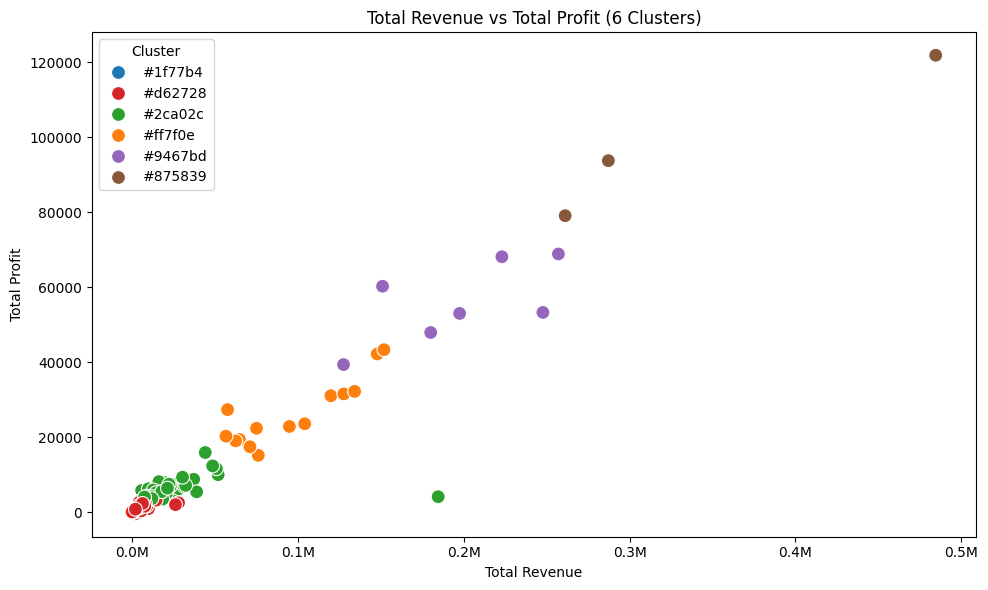

None


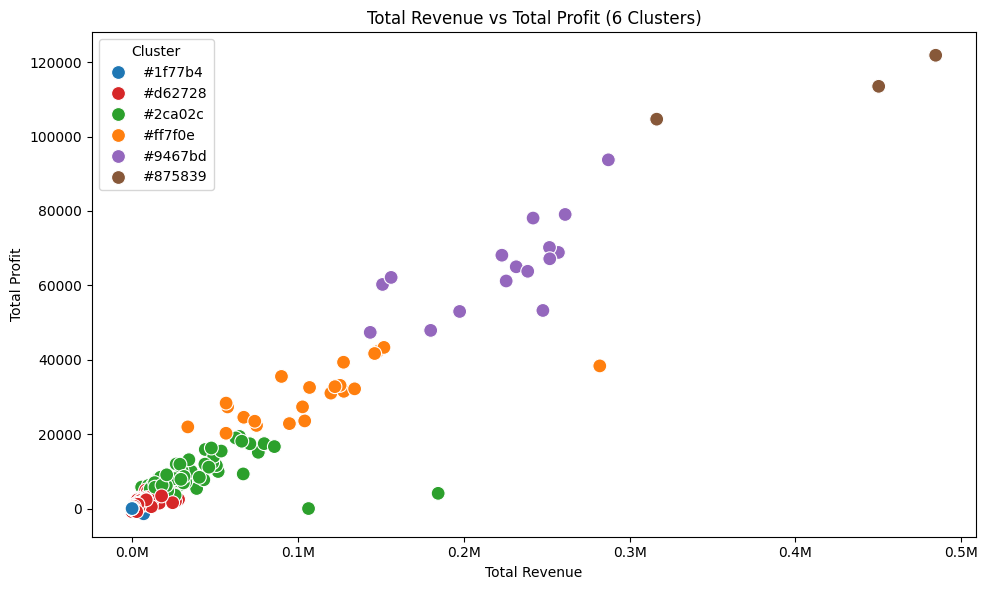

None


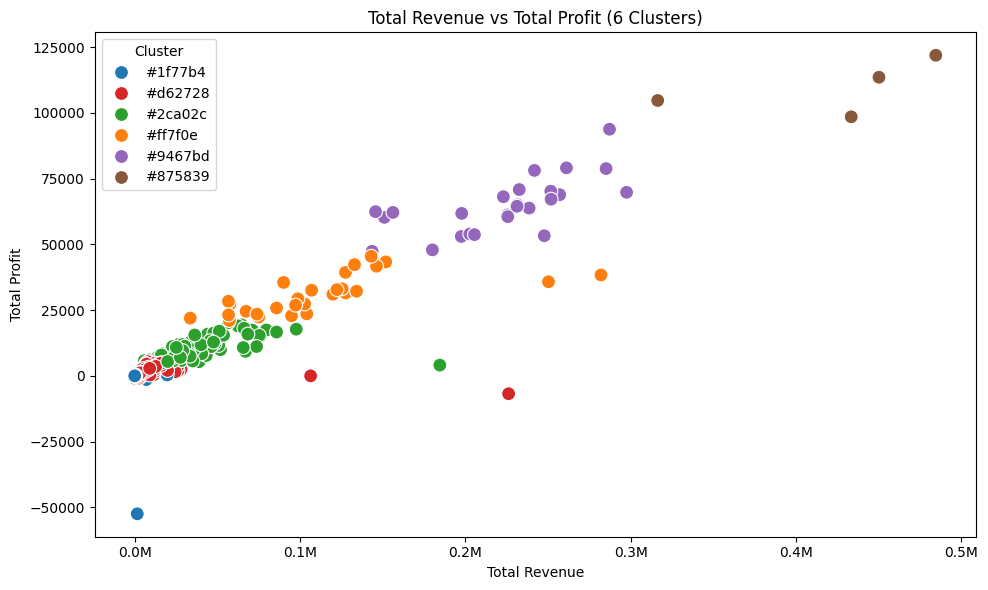

None


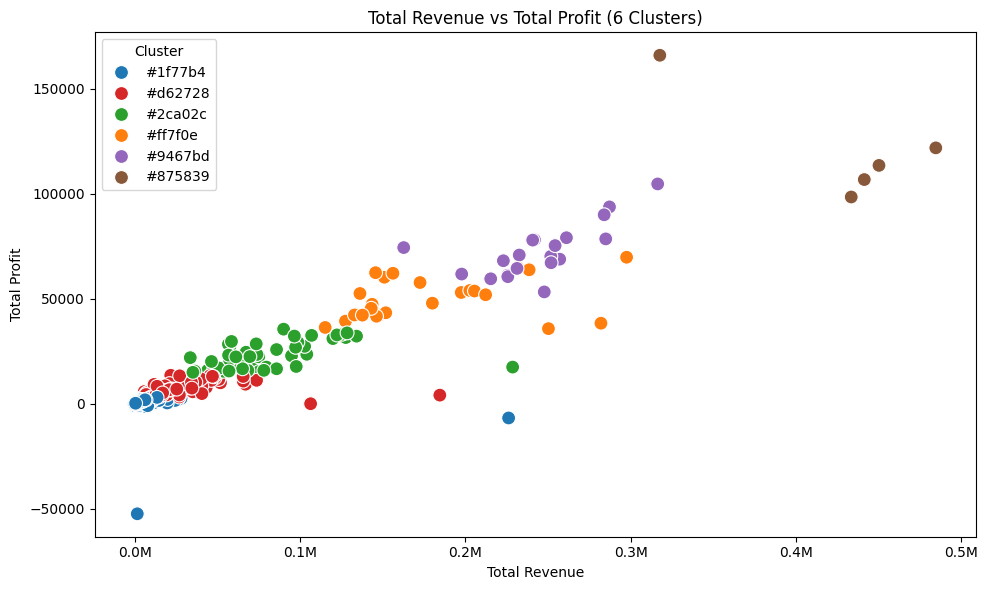

None


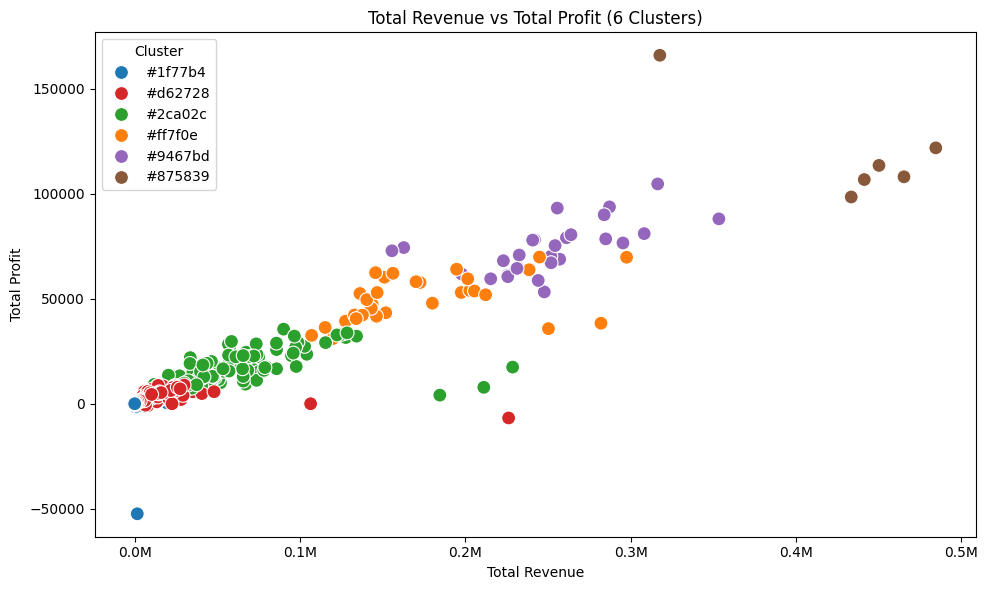

None


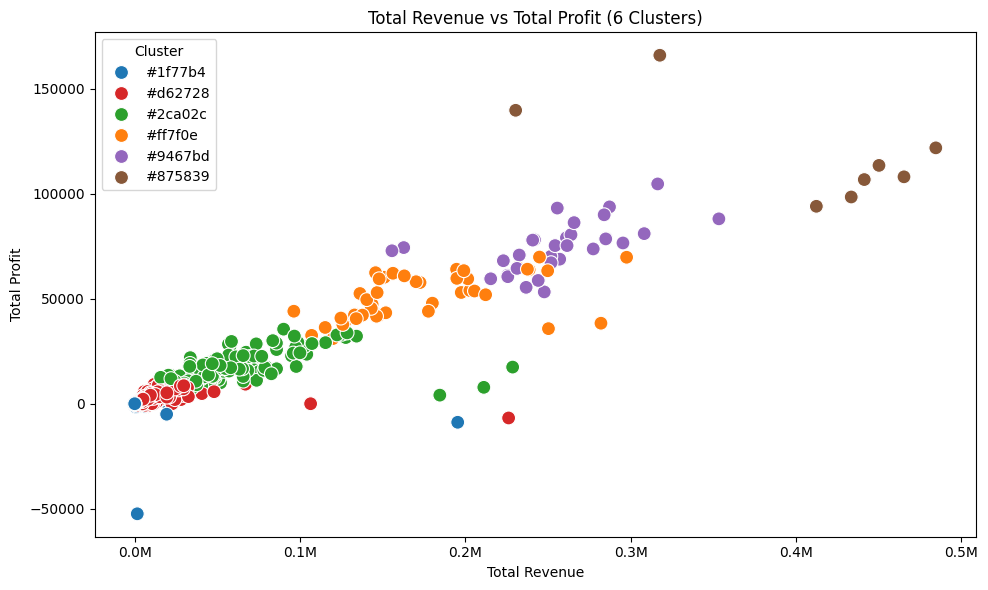

None


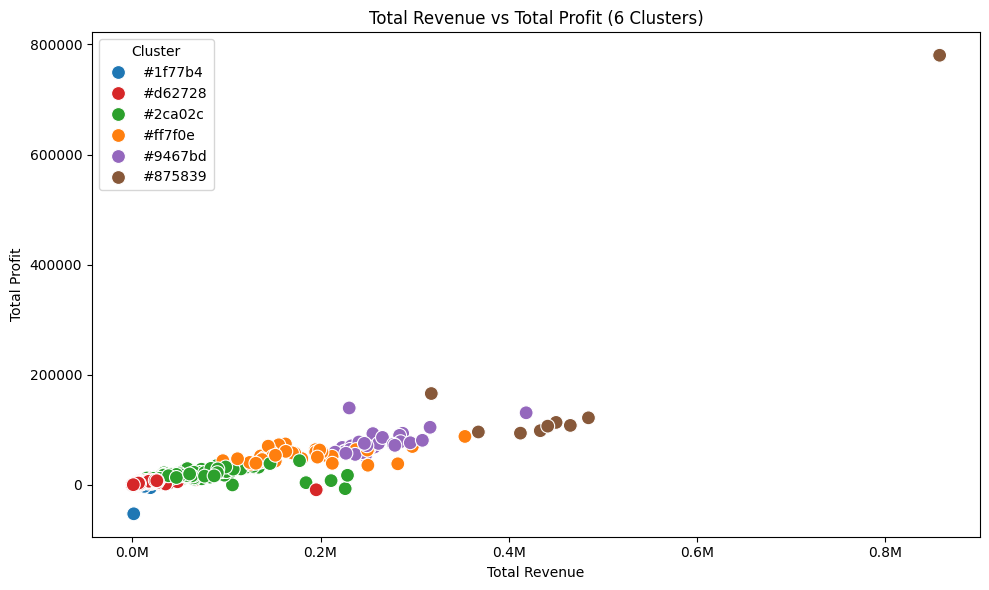

None


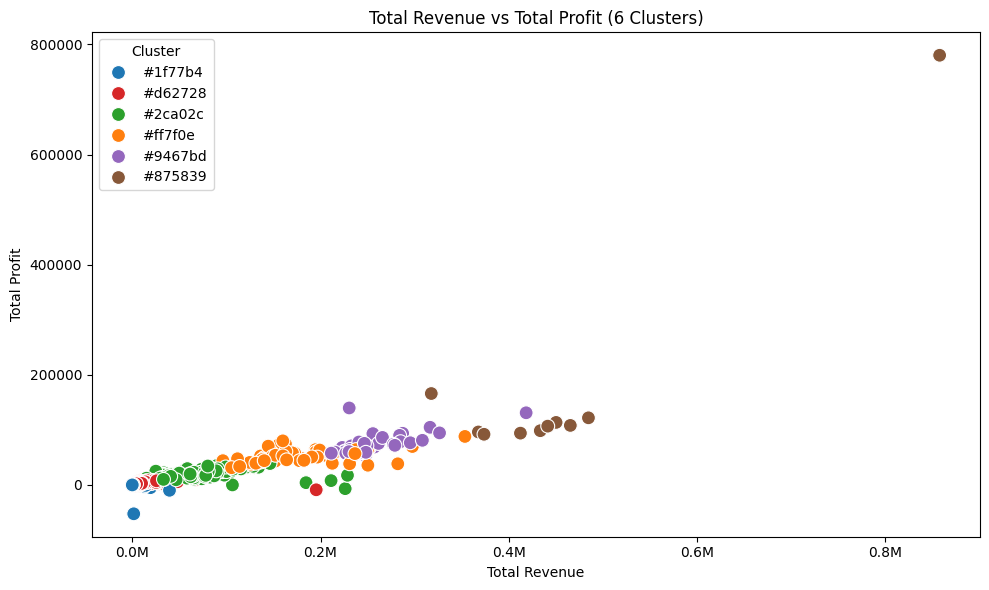

None


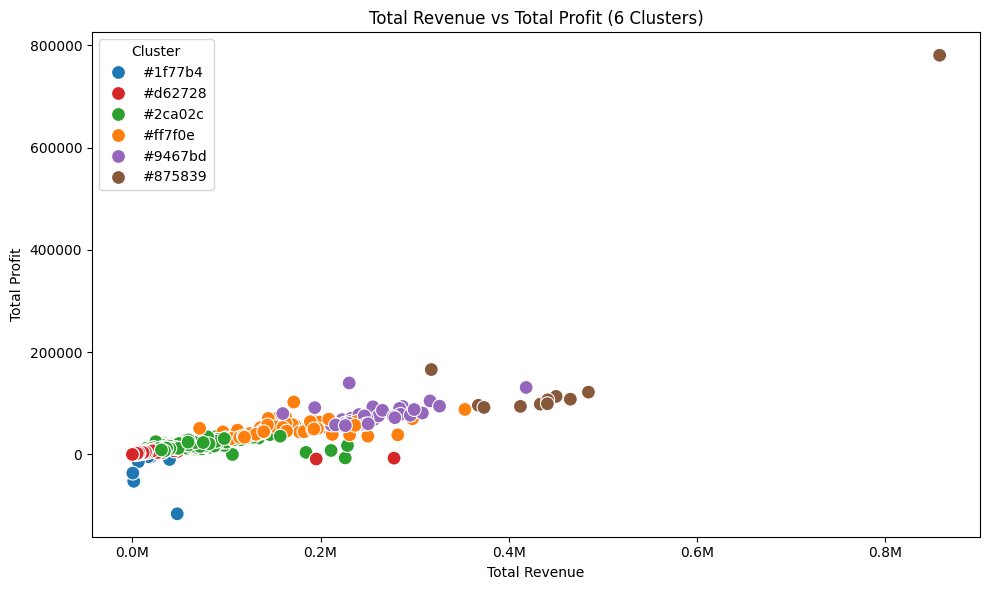

None


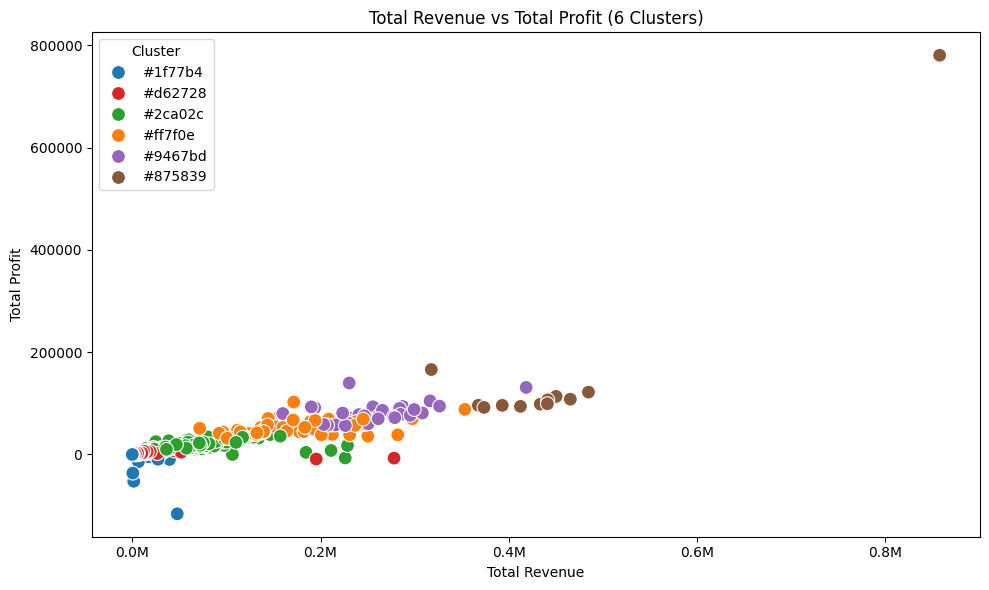

None


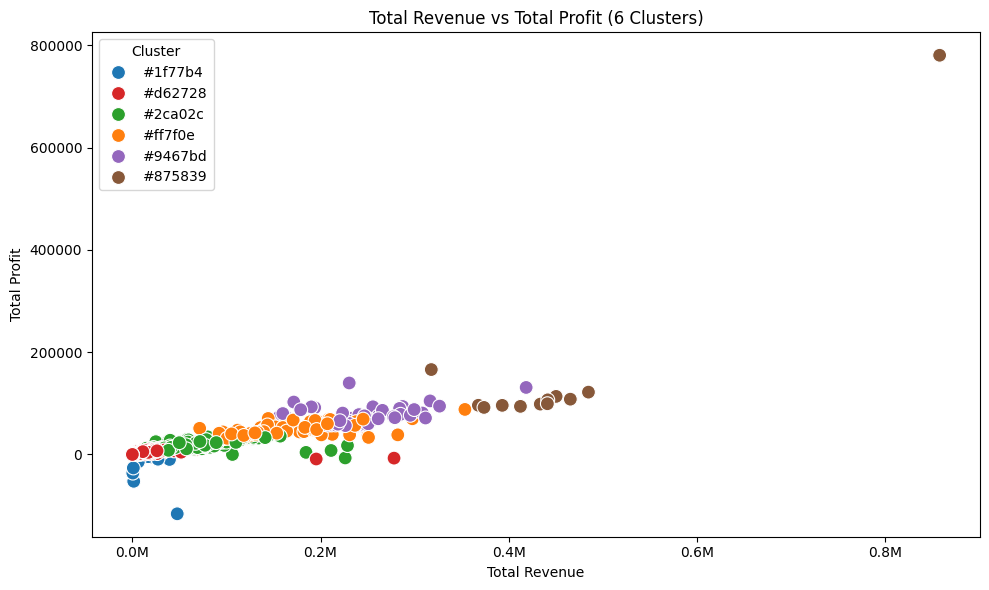

None


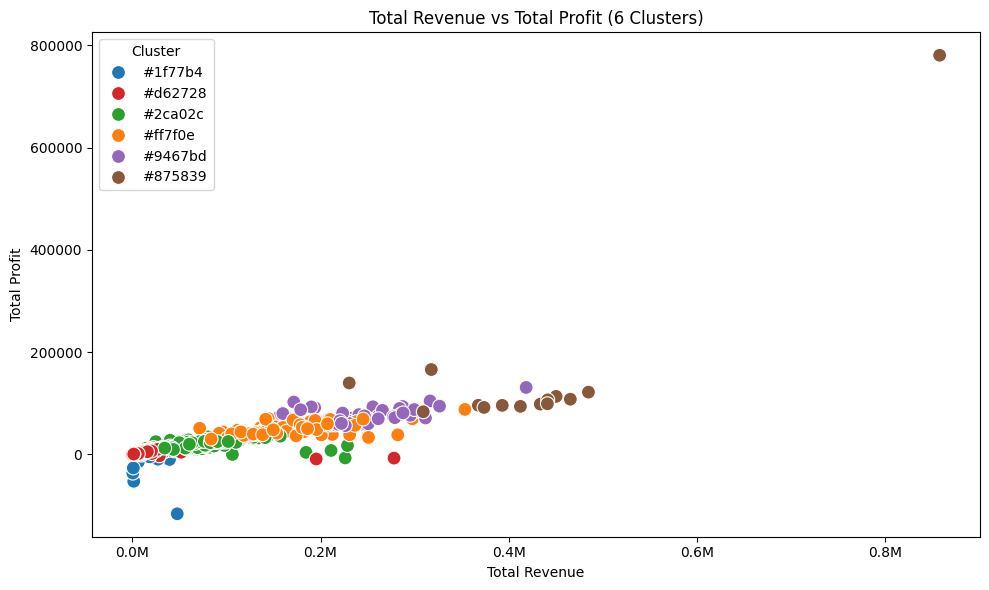

None


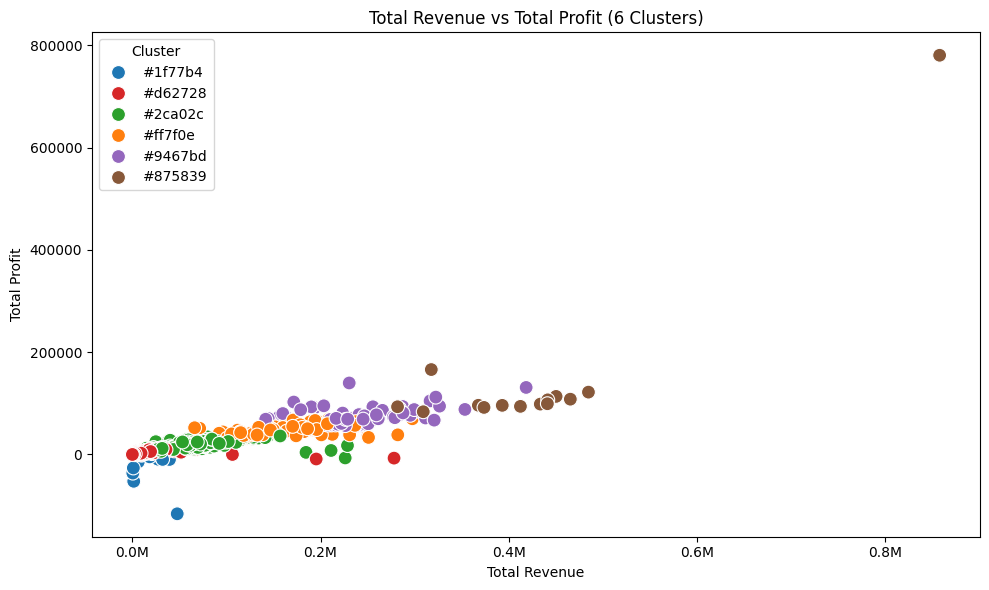

None


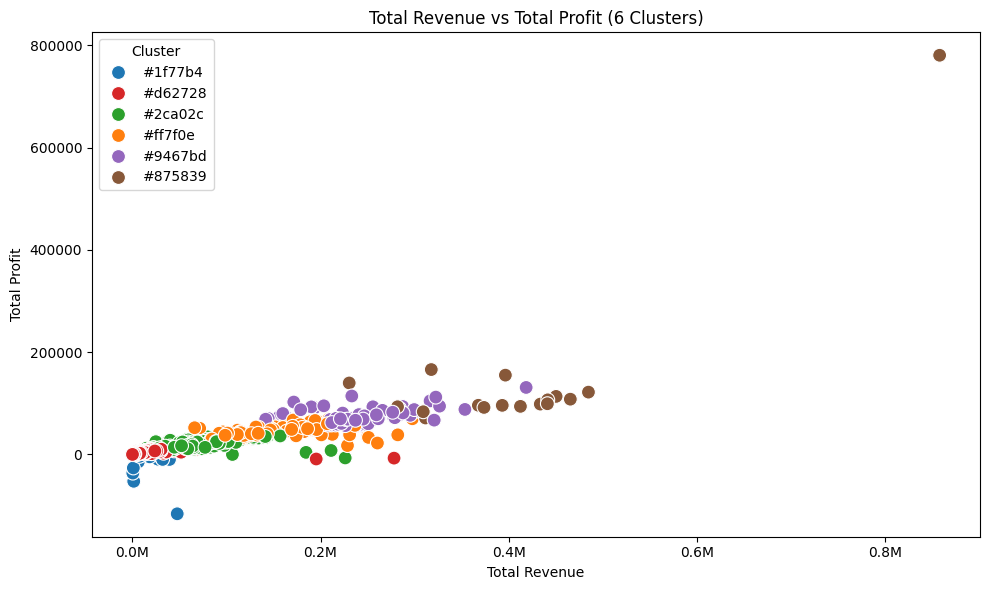

None


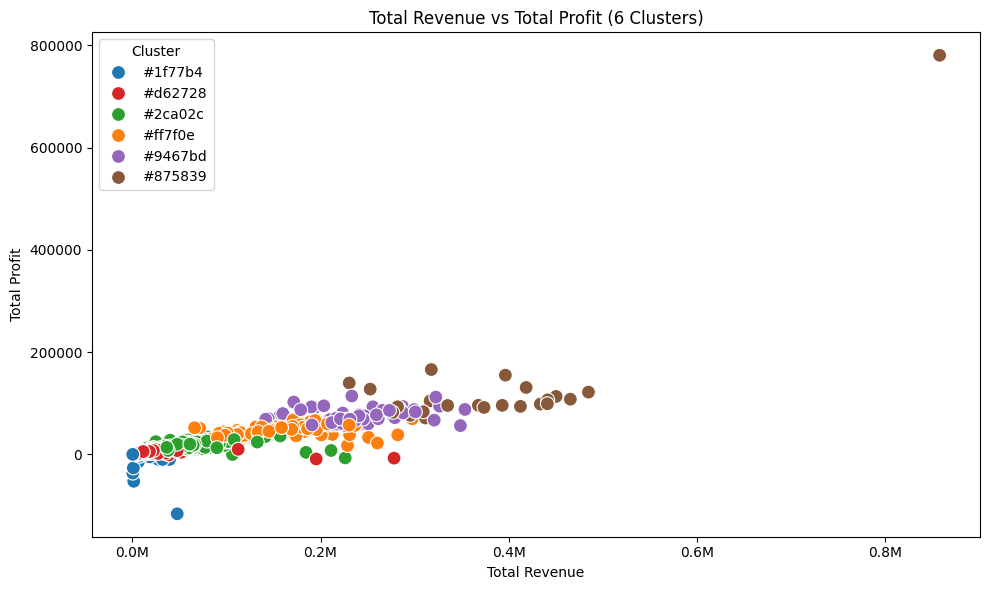

None


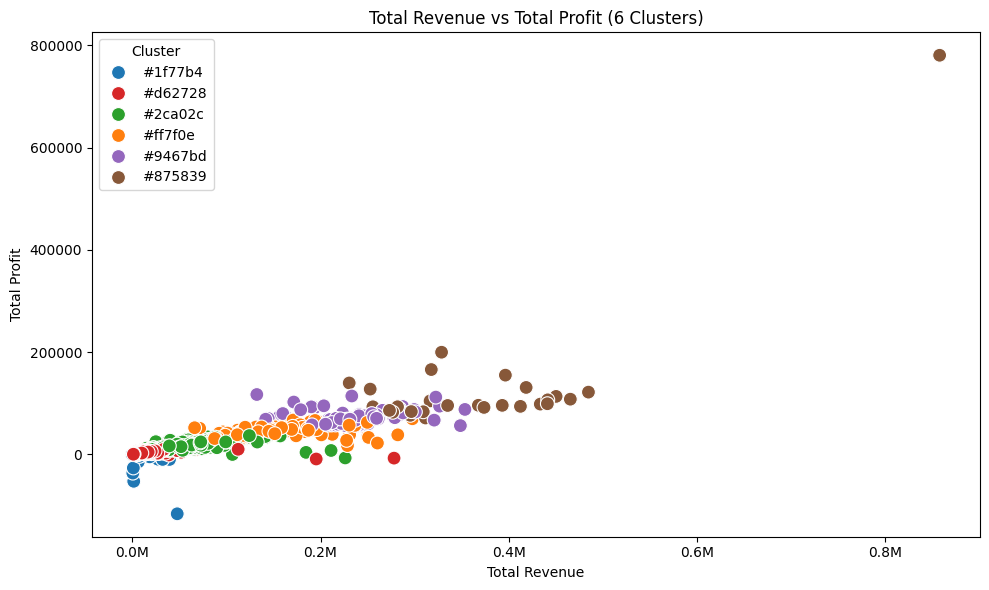

None


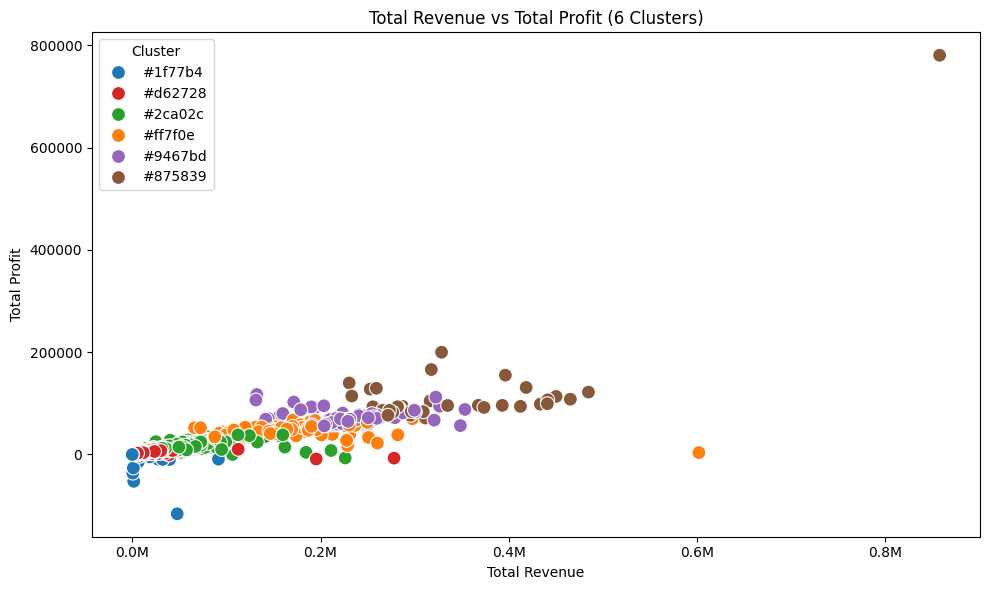

None


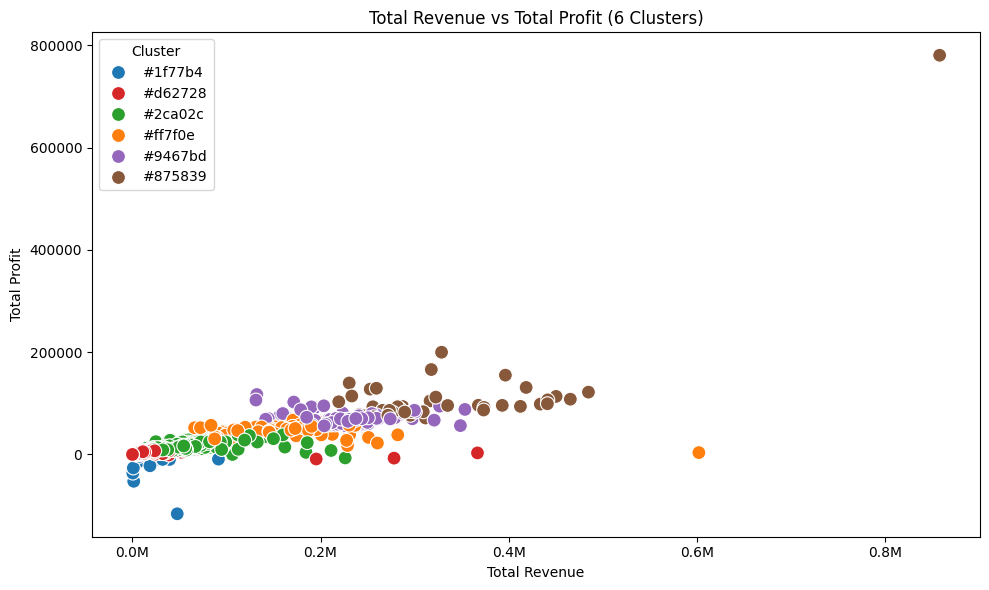

None


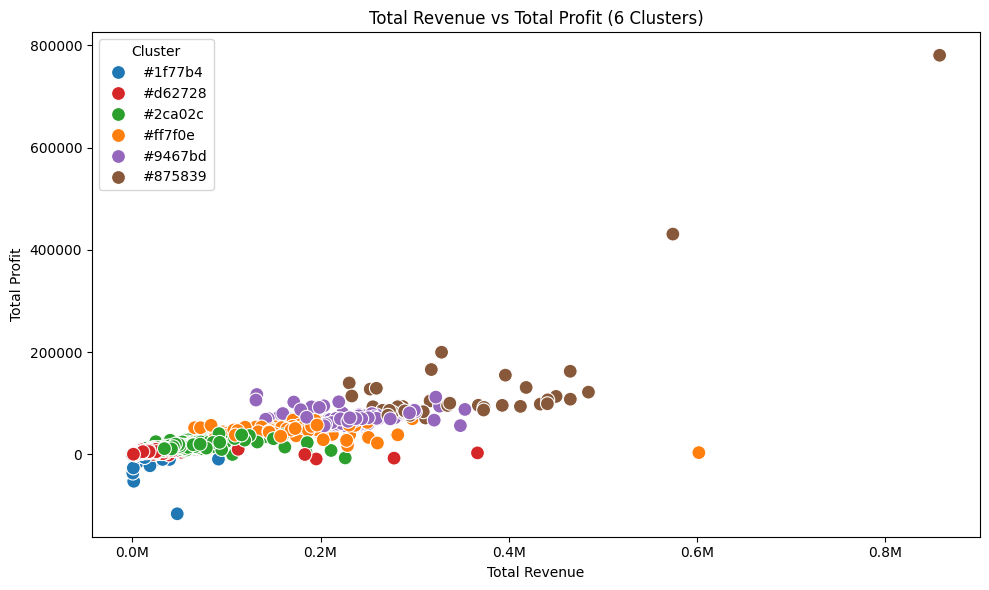

None


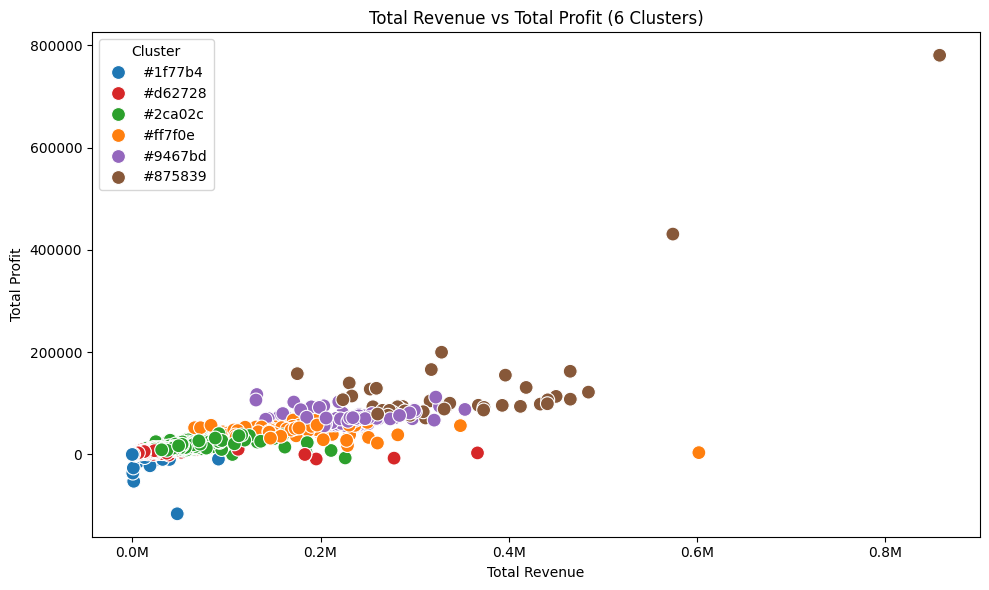

None


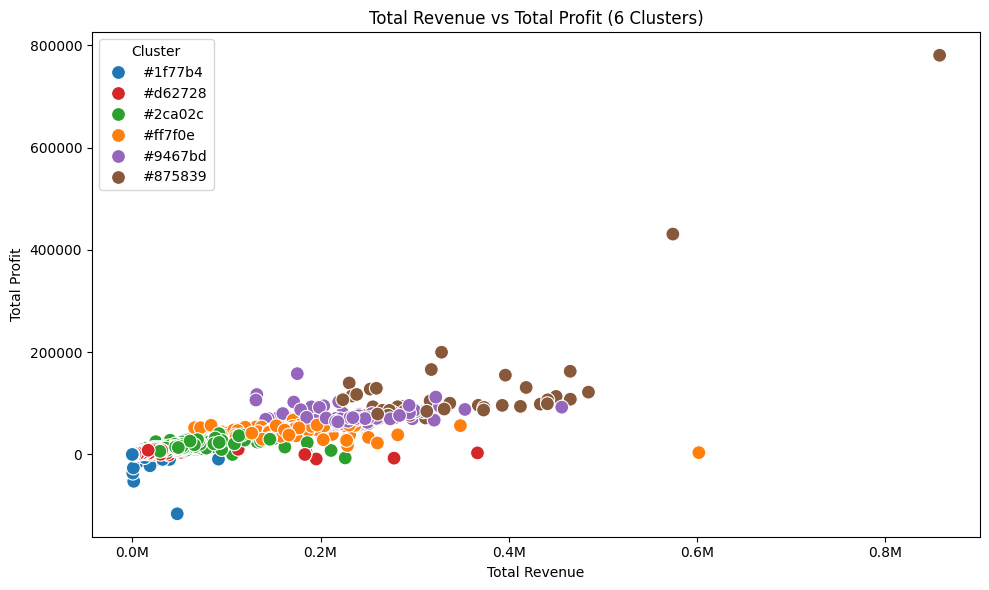

None


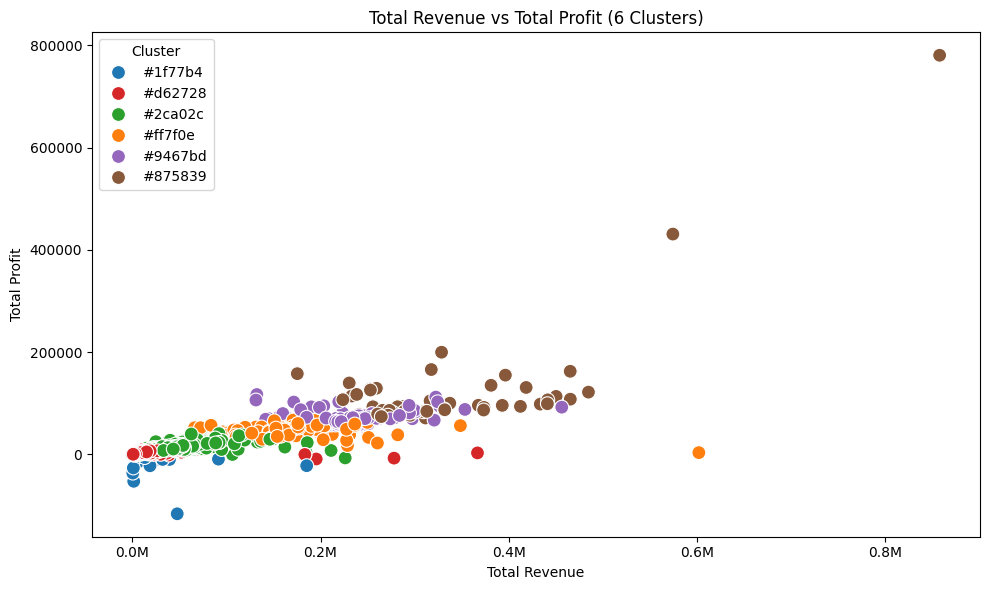

None


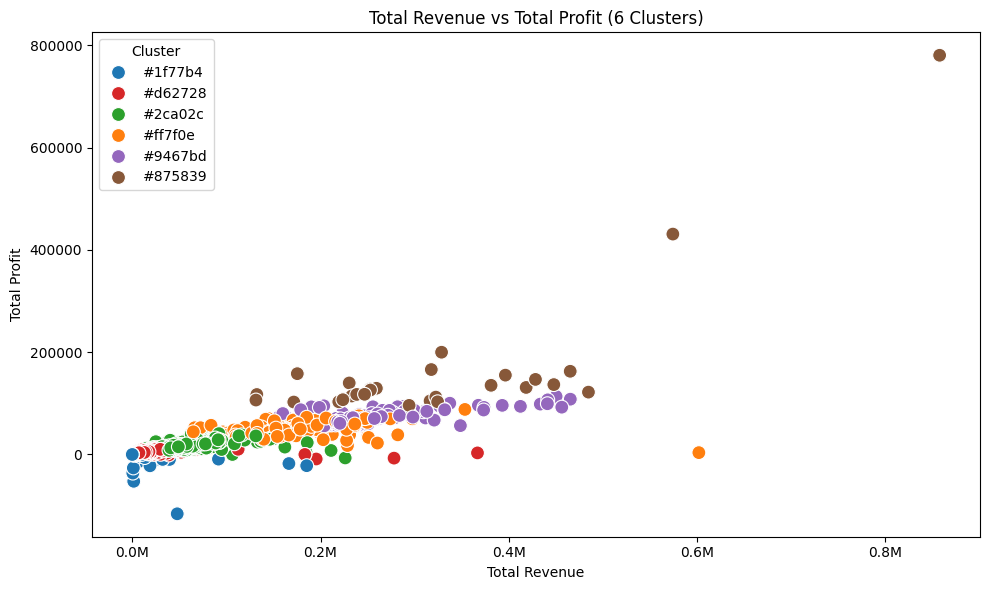

None


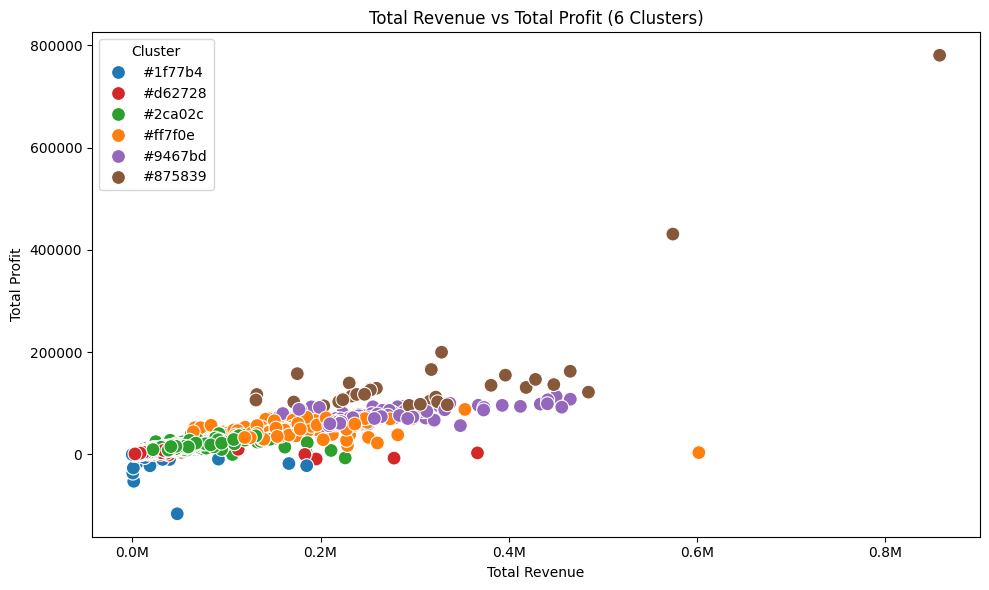

None
Updated clusters written to: ../data/processed\Monthly\customer_metrics_segmented_Monthly_00001.csv
Updated clusters written to: ../data/processed\Monthly\customer_metrics_segmented_Monthly_00002.csv
Updated clusters written to: ../data/processed\Monthly\customer_metrics_segmented_Monthly_00003.csv
Updated clusters written to: ../data/processed\Monthly\customer_metrics_segmented_Monthly_00004.csv
Updated clusters written to: ../data/processed\Monthly\customer_metrics_segmented_Monthly_00005.csv
Updated clusters written to: ../data/processed\Monthly\customer_metrics_segmented_Monthly_00006.csv
Updated clusters written to: ../data/processed\Monthly\customer_metrics_segmented_Monthly_00007.csv
Updated clusters written to: ../data/processed\Monthly\customer_metrics_segmented_Monthly_00008.csv
Updated clusters written to: ../data/processed\Monthly\customer_metrics_segmented_Monthly_00009.csv
Updated clusters written to: ../data/processed\Monthly\customer_metrics_segmented_Monthly_00010

In [65]:
# Assume feature_columns, standardScaler, weights, and CLUSTER_NUMBER are defined previously

# Step 1: Read and combine all processed files
combined_dfs = []
file_map = []  # List to remember which rows come from which file
start_idx = 0
StandardScaler = StandardScaler()

for file in os.listdir(processed_filepath):
    if file.endswith(".csv"):
        file_path = os.path.join(processed_filepath, file)
        df = pd.read_csv(file_path)
        # Save original file info (file path and row indices)
        n_rows = df.shape[0]
        file_map.append((file_path, start_idx, start_idx + n_rows))
        start_idx += n_rows
        combined_dfs.append(df)

        combined_df = pd.concat(combined_dfs, ignore_index=True)

        # Step 2: Run fuzzy clustering on the combined data

        # Extract features and scale them
        data_features = combined_df[features_columns]
        normalizedFeatures = StandardScaler.fit_transform(data_features)
        weightedFeatures = normalizedFeatures * weights
        if CLUSTERING_METHOD == 'Fuzzy':
            fuzziness_parameter = 2
            center, u, u0, distance, cost, partition_coeff, fuzz_partition_coeff = fuzz.cluster.cmeans(
                weightedFeatures.T, CLUSTER_NUMBER, fuzziness_parameter, error=.005, maxiter=1000
            )

            # Compute hard cluster assignments
            hard_labels = np.argmax(u, axis=0)

        elif CLUSTERING_METHOD == 'Hierarchical':
            hierarchical_6 = AgglomerativeClustering(n_clusters=CLUSTER_NUMBER)
            hard_labels = hierarchical_6.fit_predict(weightedFeatures)
            
        elif CLUSTERING_METHOD == 'KMeans':
            kmeans = KMeans(n_clusters=CLUSTER_NUMBER, random_state=42)
            hard_labels = kmeans.fit_predict(weightedFeatures)

        # Compute weighted average revenue for ordering (assumes column 0 is revenue)
        avg_revenue = []
        for i in range(CLUSTER_NUMBER):
            # Select the revenue values from customer_metrics_scaled (column 0)
            revenue = normalizedFeatures[hard_labels == i, 0]
            # Compute the average revenue for cluster i
            if len(revenue) > 0:
                cluster_avg = np.mean(revenue)
            else:
                cluster_avg = 0
            avg_revenue.append(cluster_avg)
        avg_revenue = np.array(avg_revenue)

        # Create a mapping so that the lowest revenue cluster gets label 0 and the highest gets (CLUSTER_NUMBER-1)
        order = np.argsort(avg_revenue)
        mapping = np.empty_like(order)
        mapping[order] = np.arange(CLUSTER_NUMBER)
        renumbered_labels = mapping[hard_labels]

        # Assign the new cluster labels to the combined dataframe
        combined_df['Cluster'] = renumbered_labels

        # (Optional) You can include your plotting block on combined_df if desired:
        def format_millions(x, pos):
            return f'{x*1e-6:.1f}M'

        custom_palette = {
            0: "#1f77b4",  # Blue
            1: "#d62728",  # Red
            2: "#2ca02c",  # Green
            3: "#ff7f0e",  # Orange
            4: "#9467bd",  # Purple
            5: "#875839",  # Purple
        }
        sns.set_palette(list(custom_palette.values()))
        plt.figure(figsize=(10, 6))
        scatter = sns.scatterplot(data=combined_df, x='TotalRevenue', y='TotalProfit', hue='Cluster', palette=custom_palette, s=100)
        plt.title('Total Revenue vs Total Profit (6 Clusters)')
        plt.xlabel('Total Revenue')
        plt.ylabel('Total Profit')
        handles, labels = scatter.get_legend_handles_labels()
        order_labels = [list(custom_palette.keys()).index(int(label)) for label in labels if label.isdigit()]
        if order_labels:
            custom_handles = [handles[idx] for idx in order_labels]
            custom_labels = [custom_palette[int(labels[idx])] for idx in order_labels]
            plt.legend(custom_handles, custom_labels, title='Cluster')
        plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_millions))
        plt.tight_layout()
        print(plt.show())

# Step 3: Write the cluster assignments back to their original files
for (file_path, start, end) in file_map:
    # Extract the rows belonging to this file
    df_update = combined_df.iloc[start:end].copy()
    # Reorder columns to put "CustomerName" first (if desired)
    cols = ["CustomerName"] + [col for col in df_update.columns if col not in ["CustomerName"]]
    df_update = df_update[cols]
    df_update.to_csv(file_path, index=False)
    print(f"Updated clusters written to: {file_path}")

In [66]:

output_filepath = os.path.join(OUTPUT_DIR, "processed", "clustered")
# Create the output directory if it doesn't exist
os.makedirs(output_filepath, exist_ok=True)
output_file = pd.DataFrame()
files = os.listdir(processed_filepath)

if TESTING:
    for i in range(files.__len__()-EARLY_STOP_COUNT):
        file = files[i]
        file_path = os.path.join(processed_filepath, file)
        output_file = pd.concat([output_file, pd.read_csv(file_path)], ignore_index=True)
    output_file_path = os.path.join(output_filepath, f"testing_stop{EARLY_STOP_COUNT}_{TIME_SEPERATION}.csv")
else:
    for i in range(files.__len__()):
        file = files[i]
        file_path = os.path.join(processed_filepath, file)
        output_file = pd.concat([output_file, pd.read_csv(file_path)], ignore_index=True)
    output_file_path = os.path.join(output_filepath, f"complete_{TIME_SEPERATION}.csv")
        
# Save the combined DataFrame to a CSV file
output_file.to_csv(output_file_path, index=False)
print(f"Combined customer metrics saved to {output_file_path}")



Combined customer metrics saved to ../data/processed\clustered\complete_Monthly.csv


In [67]:
# Load dataset
data = output_file   

In [68]:
# Define segment to index mapping
segments = ['Rock','Bronze','Silver', 'Gold', 'Diamond', 'Platinum']
cluster_to_segment = {0: 'Rock', 1: 'Bronze',2:'Silver', 3: 'Gold', 4: 'Diamond',5: 'Platinum'} 
segment_to_index = {segment: i for i, segment in enumerate(segments)}
n_segments = len(segments)

In [69]:
# Creating Transition Counts 
transition_counts = np.zeros((n_segments, n_segments), dtype=int)

for customer_id, group in data.groupby('CustomerName'):
    clusters_sequence = group['Cluster'].map(cluster_to_segment).values  # Convert clusters to segments
    for i in range(len(clusters_sequence) - 1):
        current_segment = clusters_sequence[i]
        next_segment = clusters_sequence[i + 1]
        if current_segment in segment_to_index and next_segment in segment_to_index:
            current_index = segment_to_index[current_segment]
            next_index = segment_to_index[next_segment]
            transition_counts[current_index, next_index] += 1

In [70]:
# Creating Transition matrix with calculated transition counts 
epsilon = 1e-10
transition_matrix = transition_counts / transition_counts.sum(axis=1, keepdims=True)
transition_matrix = np.nan_to_num(transition_matrix, nan=0) # Handle rows with no transitions
print(transition_counts)



[[10270  2444     6     2     0     2]
 [ 2584  6780    84     8     0     2]
 [    8    90   315    16     1     1]
 [    4     6    23   123    13     8]
 [    1     0     0    18    91     2]
 [    1     1     1     5     6    15]]


In [71]:
# (Optional) Create a DataFrame for visualization:
transition_matrix_df = pd.DataFrame(
    transition_matrix,
    index=segments,   # your tier labels
    columns=segments
)
print("Smoothed Transition Matrix:")
print(transition_matrix_df)

Smoothed Transition Matrix:
              Rock    Bronze    Silver      Gold   Diamond  Platinum
Rock      0.807136  0.192078  0.000472  0.000157  0.000000  0.000157
Bronze    0.273208  0.716853  0.008881  0.000846  0.000000  0.000211
Silver    0.018561  0.208817  0.730858  0.037123  0.002320  0.002320
Gold      0.022599  0.033898  0.129944  0.694915  0.073446  0.045198
Diamond   0.008929  0.000000  0.000000  0.160714  0.812500  0.017857
Platinum  0.034483  0.034483  0.034483  0.172414  0.206897  0.517241


In [72]:
# Assign minimum thresholds
thresholds = {
    0: 0.01,  # Rock (No threshold)
    1: 0.01,  # Bronze
    2: 0.05,  # Silver
    3: 0.05,  # Gold
    4: 0.05,  # Diamond
    5: 0.05    # Platinum
}

In [73]:

UPPER_THRESHOLD = 70
LOWER_THRESHOLD = 30

In [74]:

def normalize_weights(values):
    "Normalize values to range [0, 1] using Min-Max Scaling."
    min_val, max_val = np.min(values), np.max(values)
    return (values - min_val) / (max_val - min_val) if max_val > min_val else np.ones_like(values)

def predict_next_cluster(current_cluster, transition_matrix, TotalRevenue, TotalProfit, all_revenues, all_profits):
    "Predict the next cluster with customer-specific weighted probabilities."
    
    # Normalize revenue and profit for individual scaling
    norm_revenue = normalize_weights(np.array(all_revenues))
    norm_profit = normalize_weights(np.array(all_profits))

    # Compute individual weight (relative to dataset)
    customer_weight = (0.7 * norm_revenue[np.where(all_revenues == TotalRevenue)][0]) + \
                      (0.3 * norm_profit[np.where(all_profits == TotalProfit)][0])

    # Extract transition probabilities for current cluster
    transitional_prob = transition_matrix[current_cluster]
    scaling_factor = 6 # Adjust this value to control spread
    weighted_probabilities = np.exp(transitional_prob * customer_weight * scaling_factor)

    # Adjust probabilities using weighted softmax to enhance differentiation
    probabilities = weighted_probabilities / np.sum(weighted_probabilities)

    # Handle cases where probability sum is zero
    if np.sum(probabilities) == 0:
        return current_cluster, 0  

    # Select the most likely next cluster
    next_cluster_idx = np.argmax(probabilities)
    probability = probabilities[next_cluster_idx]

    return next_cluster_idx, probability

def apply_prediction(row, all_revenues, all_profits):
    next_cluster, prob = predict_next_cluster(row['Cluster'], transition_matrix, 
                                              row['TotalRevenue'], row['TotalProfit'], 
                                              all_revenues, all_profits)
    scaling_factor_prob = 2
    prob = prob * 100 * scaling_factor_prob
    #print(f"prob for customer {row['CustomerName']}: {prob}")

    if row['Cluster'] == 5 and prob >= UPPER_THRESHOLD:
        adjusted_cluster = 5
    elif prob >= UPPER_THRESHOLD and row['Cluster'] != 5:
        adjusted_cluster = (row['Cluster'] + 1)
    elif LOWER_THRESHOLD <= prob < UPPER_THRESHOLD or row['Cluster'] == 0 and prob <= LOWER_THRESHOLD:
        adjusted_cluster = row['Cluster']
    else:
        adjusted_cluster = row['Cluster'] - 1
    
    return pd.Series([adjusted_cluster, prob])

# Collect all revenues and profits for normalization
all_revenues = data['TotalRevenue'].values
all_profits = data['TotalProfit'].values

# Apply the new prediction method
data[['nextCluster', 'AssignedProb']] = data.apply(lambda row: apply_prediction(row, all_revenues, all_profits), axis=1)
data['AssignedProb'] = (data['AssignedProb']).round(3).clip(10,100)




In [75]:
# Calculate revenue and profit growth per customer
data['RevenueGrowth'] = data.groupby('CustomerName')['TotalRevenue'].pct_change().fillna(0).round(3)*100
data['ProfitGrowth'] = data.groupby('CustomerName')['TotalProfit'].pct_change().fillna(0).round(3)*100

def probability_of_moving_up(customer_row, transition_matrix):
    current_cluster = int(customer_row['Cluster'])

    if current_cluster >= len(transition_matrix):
        return 0.0

    # Base probability of promotion
    base_prob = sum(transition_matrix[current_cluster][current_cluster + 1:])

    if base_prob == 0:
        return 0.0

    # Get growth metrics, handle bad data
    rev_growth = customer_row.get('RevenueGrowth', 0)
    prof_growth = customer_row.get('ProfitGrowth', 0)

    if not np.isfinite(rev_growth): rev_growth = 0
    if not np.isfinite(prof_growth): prof_growth = 0
    if np.isnan(rev_growth): rev_growth = 0
    if np.isnan(prof_growth): prof_growth = 0

    # Scaled growth score
    growth_score = 0.8 * rev_growth + 0.2 * prof_growth

    # Sigmoid scale to smooth and bound the influence of growth
    # Example: -100 => ~0, 0 => 0.5, 30 => ~0.95
    sigmoid = lambda x: 1 / (1 + np.exp(-x / 15))
    boost_factor = sigmoid(growth_score)

    # Final move-up probability (allow boost up to 3x base, capped at 1)
    adjusted_prob = min(1.0, base_prob * (1 + 2 * boost_factor))  # up to 3x

    return round(adjusted_prob * 100,2)

data['MoveUpProbability'] = data.apply(lambda row: probability_of_moving_up(row, transition_matrix), axis=1)

C:\Users\astro\AppData\Local\Temp\ipykernel_25816\2445240616.py:31: RuntimeWarning: overflow encountered in exp
  sigmoid = lambda x: 1 / (1 + np.exp(-x / 15))


In [76]:
def apply_threshold(cluster, next_cluster, probability):
    threshold = thresholds[cluster]
    if next_cluster > cluster:   # Moving Up
        return "Moving Up"
    elif next_cluster < cluster: # Moving Down + Probability above threshold
        return "At Risk"
    elif next_cluster == cluster:
        return "Safe"
    
data['RiskLevel'] = data.apply(lambda row: apply_threshold(row['Cluster'], row['nextCluster'], row['AssignedProb']), axis=1)

In [77]:

data['Current_Tier'] = data['Cluster'].map(cluster_to_segment)
data['Next_Tier'] = data['nextCluster'].astype(int).map(cluster_to_segment)
data['Risk_Cluster_Tier_Pair'] = (
    data['Cluster'].astype(str) + '-' + 
    data['nextCluster'].astype(str) + '-' + 
    data['RiskLevel'] + '-' + 
    data['Current_Tier'] + '-' + 
    data['Next_Tier']
)


In [78]:
def determine_risk(prob):
    if prob > UPPER_THRESHOLD:
        return "Moving Up"
    elif prob >= LOWER_THRESHOLD and prob<UPPER_THRESHOLD:
        return "Safe"
    else:
        return "At Risk"

def custom_risk_aggregation(group, prob):
    group = group.dropna()  # Drop NaN values to prevent errors
    if group.empty:
        return "0-0-Safe-Rock-Rock"  # or some fallback default
    mode_values = group.mode()
    if mode_values.empty:
        return "0-0-Safe-Rock-Rock"

    mode_str = mode_values.iloc[0]

    if isinstance(mode_values, pd.Series) and mode_values.str.contains("Moving Up").any():
        risk_category = determine_risk(prob)
        moving_up_rows = group[group.str.contains("Moving Up", na=False)]
        if not moving_up_rows.empty:
            return moving_up_rows.iloc[0]
        base_values = mode_str.split('-')
        return f"{base_values[0]}-{base_values[1]}-{risk_category}-{base_values[3]}-{base_values[4]}"
    else:
        return mode_str



In [79]:

# Aggregate results per customer
aggregated = data.groupby([ 'CustomerName'], sort=False).agg({
    'TotalRevenue': 'mean',
    'TotalProfit': 'mean',
    'AssignedProb': 'mean',
    'MoveUpProbability' :'mean'
}).reset_index()

#aggregated[['Current_Tier', 'Next_Tier']] = aggregated['Tier_Pair'].str.split('-', expand=True)
aggregated['Risk_Cluster_Tier_Pair'] = data.groupby(['CustomerName'])\
    .apply(lambda group: custom_risk_aggregation(group['Risk_Cluster_Tier_Pair'], group['AssignedProb'].mean()))\
    .reset_index(drop=True)
aggregated[['Cluster', 'nextCluster','RiskLevel','Current_Tier','Next_Tier']] = aggregated['Risk_Cluster_Tier_Pair'].str.split('-', expand=True)
aggregated['Cluster'] = aggregated['Cluster'].astype(int)
aggregated['nextCluster'] = aggregated['nextCluster'].astype(float)
aggregated.drop(columns=['Risk_Cluster_Tier_Pair'], inplace=True) # Drop the temporary column

aggregated['AssignedProb'] = aggregated['AssignedProb'].round(3)
aggregated['MoveUpProbability'] = aggregated['MoveUpProbability'].round(3)
aggregated['TotalRevenue'] = aggregated['TotalRevenue'].round(2)
aggregated['TotalProfit'] = aggregated['TotalProfit'].round(2)

# Print the aggregated results for review
print("\n Aggregated Customer Risk Overview:\n")
print(aggregated.head(15))



 Aggregated Customer Risk Overview:

                       CustomerName  TotalRevenue  TotalProfit  AssignedProb  \
0                ADAMS PLC AND SONS       2460.92      1061.02        38.694   
1                     ADAMS PLC LTD         29.15         6.30        38.538   
2   AHMED, MURPHY AND STEVENSON LLC         26.94        11.37        38.570   
3                AHMED-BAILEY GROUP        640.42       179.32        38.442   
4                 AKHTAR-AKHTAR LTD        116.79        39.72        38.515   
5                AKHTAR-WHEELER LTD      12442.55      4103.78        39.231   
6                 ALEXANDER PLC LTD       1041.67      1041.67        38.727   
7    ALEXANDER, RUIZ AND FOSTER LLC        119.07         9.87        38.221   
8             ALI, FOX AND GRAY INC        225.36        14.67        38.590   
9       ALLEN, CARSON AND PEREZ LTD        413.18       180.03        38.288   
10                ALLEN-HARDING INC         55.74        20.13        38.574   
11

C:\Users\astro\AppData\Local\Temp\ipykernel_25816\4266537316.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: custom_risk_aggregation(group['Risk_Cluster_Tier_Pair'], group['AssignedProb'].mean()))\


In [81]:

# Save datasets
data.to_csv(os.path.join(OUTPUT_DIR, "processed", "complete_dataset_{TIME_SEPERATION}.csv"), index=False)
aggregated.to_csv("../data/raw/aggregated_dataset.csv", index=False)
aggregated.to_csv(os.path.join(OUTPUT_DIR, "processed", "clustered_customers_with_prediction_{TIME_SEPERATION}.csv"), index=False)
aggregated_dataset = pd.read_csv(os.path.join(OUTPUT_DIR, "processed", "clustered_customers_with_prediction_{TIME_SEPERATION}.csv"))

# Filter customers with RiskLevel as 'Moving up' or 'At Risk'
moving_up_customers = aggregated_dataset[aggregated_dataset['RiskLevel'] == 'Moving Up']
at_risk_customers = aggregated_dataset[aggregated_dataset['RiskLevel'] == 'At Risk']
prob_customers = aggregated_dataset[aggregated_dataset['AssignedProb'] > UPPER_THRESHOLD]
platinum_prob_customers = aggregated_dataset[(aggregated_dataset['AssignedProb'] > UPPER_THRESHOLD) & (aggregated_dataset['RiskLevel'] == 'Safe')]

# Print the relevant columns
print("\nCustomers MOVING UP:")
print(moving_up_customers[[ 'CustomerName','Current_Tier', 'Next_Tier', 'MoveUpProbability']])
print(f"\nCustomers Assigned Probability above {UPPER_THRESHOLD} and Safe:")
print(platinum_prob_customers[['CustomerName','AssignedProb']])
print("\nCustomers AT RISK:")
print(at_risk_customers[['CustomerName', 'Current_Tier', 'Next_Tier', 'AssignedProb']].head(10))



Customers MOVING UP:
                        CustomerName Current_Tier Next_Tier  MoveUpProbability
398              HUNT-BOWEN AND SONS      Diamond  Platinum              3.328
495                   LEE-BOND GROUP      Diamond  Platinum              7.448
635  OWEN, WATKINS AND TOMLINSON INC      Diamond  Platinum              9.996
682       POWELL, LEE AND ASHTON LLC      Diamond  Platinum              4.198
932                  WHEELER LLC LLC      Diamond  Platinum             11.498

Customers Assigned Probability above 70 and Safe:
            CustomerName  AssignedProb
592  MORRIS-INGRAM GROUP        70.153

Customers AT RISK:
Empty DataFrame
Columns: [CustomerName, Current_Tier, Next_Tier, AssignedProb]
Index: []


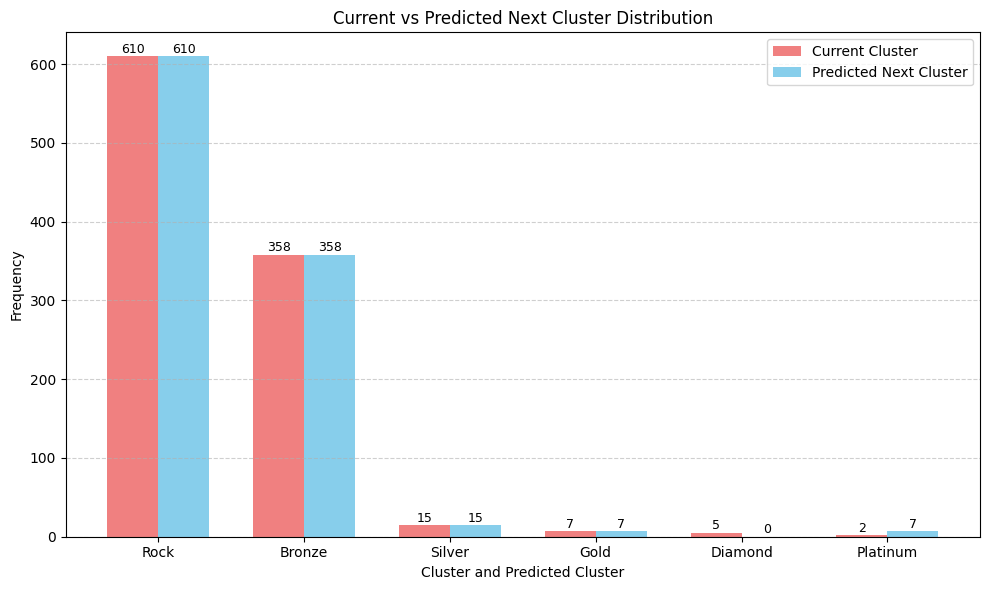

In [82]:
predicted_counts = aggregated_dataset['nextCluster'].value_counts().sort_index()
current_counts = aggregated_dataset['Cluster'].value_counts().sort_index()

# Ensure all clusters (0–5) are represented, even if missing
all_clusters = range(6)
current_counts = current_counts.reindex(all_clusters, fill_value=0)
predicted_counts = predicted_counts.reindex(all_clusters, fill_value=0)

# Bar positions
x = np.arange(len(all_clusters))  # [0, 1, 2, 3, 4, 5]
width = 0.35  # width of each bar

# Plot
plt.figure(figsize=(10, 6))
bars1 = plt.bar(x - width/2, current_counts.values, width, label='Current Cluster', color='lightcoral')
bars2 = plt.bar(x + width/2, predicted_counts.values, width, label='Predicted Next Cluster', color='skyblue')

# Add value labels on top
for bar in bars1 + bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', va='bottom', fontsize=9)

# Custom cluster labels
plt.xticks(ticks=x, labels=segments)

plt.xlabel('Cluster and Predicted Cluster')
plt.ylabel('Frequency')
plt.title('Current vs Predicted Next Cluster Distribution')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()




In [83]:
if TESTING:
    #compare the predicted clusters with the actual clusters
    predicted_counts = aggregated_dataset['nextCluster'].value_counts().sort_index()
    files = os.listdir(processed_filepath)
    actual_file = files[files.__len__()-EARLY_STOP_COUNT]
    actual_filepath = os.path.join(processed_filepath, actual_file)
    actual_data = pd.read_csv(actual_filepath)
    actual_counts = actual_data['Cluster'].value_counts().sort_index()

    # Ensure all clusters (0–5) are represented, even if missing
    all_clusters = range(6)
    actual_counts = actual_counts.reindex(all_clusters, fill_value=0)
    predicted_counts = predicted_counts.reindex(all_clusters, fill_value=0)

    # Bar positions
    x = np.arange(len(all_clusters))  # [0, 1, 2, 3, 4, 5]
    width = 0.35  # width of each bar

    # Plot
    plt.figure(figsize=(10, 6))
    bars1 = plt.bar(x - width/2, actual_counts.values, width, label='Actual Cluster', color='lightcoral')
    bars2 = plt.bar(x + width/2, predicted_counts.values, width, label='Predicted Cluster', color='skyblue')

    # Add value labels on top
    for bar in bars1 + bars2:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', va='bottom', fontsize=9)

    # Custom cluster labels
    plt.xticks(ticks=x, labels=segments)

    plt.xlabel('Cluster and Predicted Cluster')
    plt.ylabel('Frequency')
    plt.title('Actual vs Predicted Cluster Distribution')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()